# Stationarity Toolkit: Comprehensive Time Series Analysis

Stationarity testing is typically done with one or two chosen tests . But here's the problem: different tests detect different types of non-stationarity. A series might pass ADF / KPSS but fail Zivot-Andrews because one tests for unit rootes, detereministic trends while the other tests for structural breaks. Your variance might look stable when split into segments (Levene test passes) but show clear time-dependent patterns (White test fails). Likewise for seasonality, it could be a fixed repeating pattern or a random-walk seasonal component - you need different tests to tell them apart.

The **Stationarity Toolkit** addresses this by running 10 statistical tests across three categories: trend, variance, and seasonality. Instead of getting a single yes/no answer, you get a complete picture of what's happening in your time series.

But comprehensive testing reveals another challenge: transformations interact in unpredictable ways. You might difference your data to remove trend, only to discover you've introduced variance issues that weren't there before. Or you stabilize variance with Box-Cox, then find that differencing undoes your work. This is where the toolkit becomes essential - it lets you test after each transformation to see what actually happened, not what you assumed would happen.

This notebook walks through the toolkit's capabilities in four parts. We start with synthetic data where we know exactly what non-stationarity exists, then move to increasingly complex scenarios, and finally tackle real-world data where nothing behaves quite like the textbooks say it should.

For complete details on the 10 tests and their interpretations, see the [README](README.md).

In [1]:
# Install toolkit
# !pip install stationaritytoolkit

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
from stationarity_toolkit.toolkit import StationarityToolkit

# Set working directory to repo root
if os.path.basename(os.getcwd()) == 'examples':
    os.chdir('..')

# Configure pandas display for full text visibility
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

# Suppress interpolation warnings from statsmodels
warnings.filterwarnings('ignore', category=Warning)

np.random.seed(42)
toolkit = StationarityToolkit(alpha=0.05)

def plot_ts(values, title):
    plt.figure(figsize=(12, 4))
    plt.plot(values)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

## Part 1: Does the Toolkit Actually Work?

Before we trust the toolkit with real data, let's validate it on synthetic data where we know exactly what's going on. We'll create six time series with specific properties and see if the tests catch what they're supposed to catch.

We start simple - pure noise and noise with a constant baseline. Both should be stationary, and all tests should pass. Then we add a trend, which should trigger the trend tests. Next, seasonality, which should trigger the seasonal tests. Then we test two types of variance non-stationarity: smooth growth (which most variance tests should catch) and clustered volatility (which specifically the ARCH test should catch).

But validation isn't just about confirming tests work - it's also about discovering their limitations. You'll see the Zivot-Andrews test find "structural breaks" in smooth trends where none exist. You'll see the ARCH test fail when there's trend or seasonality, even though there's no volatility clustering. You'll see ACF confuse variance issues with seasonality. These aren't bugs - they're inherent limitations that you need to understand when interpreting results on real data.

### 1.1 Pure Noise (Stationary Baseline)

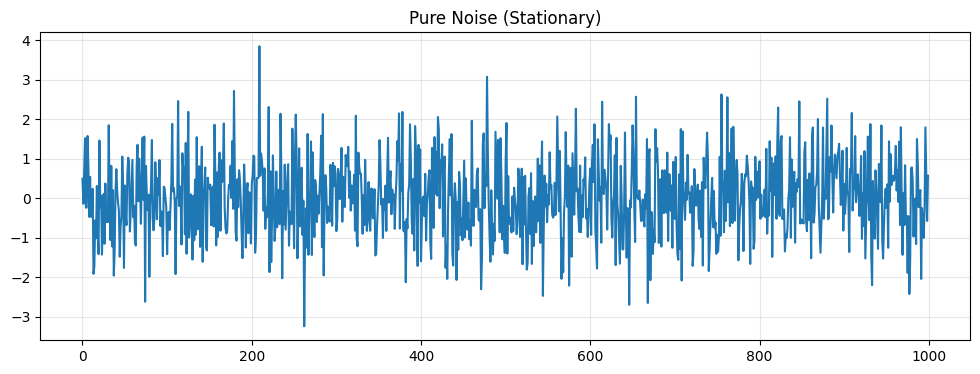

Trend Stationary: ✅ Yes
Variance Stationary: ✅ Yes
Seasonal Stationary: ✅ Yes


,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,✅ Stationary,-31.8111,0.0000,Stationary around constant mean,"H0: Unit root. ADF-c p=0.0000 < 0.05, ADF-ct p=0.0000 < 0.05. Reject H0."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,✅ Stationary,0.1871,0.1000,Stationary around constant mean,"H0: Stationary. KPSS-c p=0.1000 > 0.05, KPSS-ct p=0.1000 > 0.05. Fail to reject H0."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-31.8105,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-32.0778,0.0000,"Stationary with structural breaks: level shift at obs 428, trend shift at obs 157, level+trend shift at obs 428. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0007, ZA-ct p=0.0002 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,✅ Stationary,0.2055,0.8926,Constant variance across time,H0: Equal variances across segments. Levene p=0.8926 > 0.05. Fail to reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,✅ Stationary,0.5547,0.9067,Constant variance across time,H0: Equal variances across segments (assumes normality). Bartlett p=0.9067 > 0.05. Fail to reject H0.
6,Variance,White's Test for Heteroskedasticity,✅ Stationary,0.8660,0.6486,Constant variance across time,H0: Homoskedasticity. White p=0.6486 > 0.05. Fail to reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,✅ Stationary,5.8489,0.8278,"No volatility clustering detected (ARCH tests for clustered variance, not smooth changes)",H0: No ARCH effects. ARCH p=0.8278 > 0.05. Fail to reject H0.
8,Seasonal,ACF/PACF Peak Detection,✅ Stationary,0.0800,1.0000,No seasonal patterns detected,H0: No seasonality. Ljung-Box p=1.0000 >= 0.05. Fail to reject H0.
9,Seasonal,STL Decomposition,✅ Stationary,0.1521,1.0000,No significant seasonal component detected,H0: No seasonality. F-stat p=1.0000 > 0.05. Fail to reject H0.


In [24]:
n = 1000
ts_noise = pd.Series(
    np.random.normal(0, 1, n),
    index=pd.date_range('2020-01-01', periods=n, freq='D')
)
plot_ts(ts_noise.values, "Pure Noise (Stationary)")

result = toolkit.detect(ts_noise, verbosity='detailed')
print(result.summary)
result.report(filepath='examples/case1_noise_report.md')

All tests pass - validates toolkit correctly identifies stationary data.

### 1.2 Noise + Baseline (Stationary)

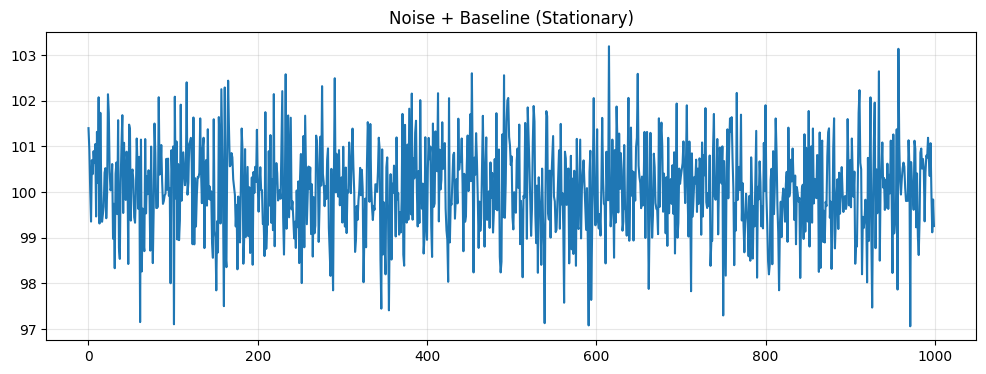

Trend Stationary: ✅ Yes
Variance Stationary: ✅ Yes
Seasonal Stationary: ✅ Yes


,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,✅ Stationary,-32.0477,0.0000,Stationary around constant mean,"H0: Unit root. ADF-c p=0.0000 < 0.05, ADF-ct p=0.0000 < 0.05. Reject H0."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,✅ Stationary,0.1149,0.1000,Stationary around constant mean,"H0: Stationary. KPSS-c p=0.1000 > 0.05, KPSS-ct p=0.1000 > 0.05. Fail to reject H0."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-32.1132,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-32.1820,0.0000,"Stationary with structural breaks: level shift at obs 373, trend shift at obs 185, level+trend shift at obs 771. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0007, ZA-ct p=0.0002 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,✅ Stationary,0.2491,0.8620,Constant variance across time,H0: Equal variances across segments. Levene p=0.8620 > 0.05. Fail to reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,✅ Stationary,0.6772,0.8786,Constant variance across time,H0: Equal variances across segments (assumes normality). Bartlett p=0.8786 > 0.05. Fail to reject H0.
6,Variance,White's Test for Heteroskedasticity,✅ Stationary,0.3723,0.8302,Constant variance across time,H0: Homoskedasticity. White p=0.8302 > 0.05. Fail to reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,✅ Stationary,4.7745,0.9057,"No volatility clustering detected (ARCH tests for clustered variance, not smooth changes)",H0: No ARCH effects. ARCH p=0.9057 > 0.05. Fail to reject H0.
8,Seasonal,ACF/PACF Peak Detection,✅ Stationary,0.0709,1.0000,No seasonal patterns detected,H0: No seasonality. Ljung-Box p=1.0000 >= 0.05. Fail to reject H0.
9,Seasonal,STL Decomposition,✅ Stationary,0.1343,1.0000,No significant seasonal component detected,H0: No seasonality. F-stat p=1.0000 > 0.05. Fail to reject H0.


In [25]:
ts_baseline = pd.Series(
    100 + np.random.normal(0, 1, n),
    index=pd.date_range('2020-01-01', periods=n, freq='D')
)
plot_ts(ts_baseline.values, "Noise + Baseline (Stationary)")

result = toolkit.detect(ts_baseline, verbosity='detailed')
print(result.summary)
result.report(filepath='examples/case2_baseline_report.md')

All tests pass - baseline shift doesn't affect stationarity.

### 1.3 Noise + Baseline + Trend (Non-Stationary)

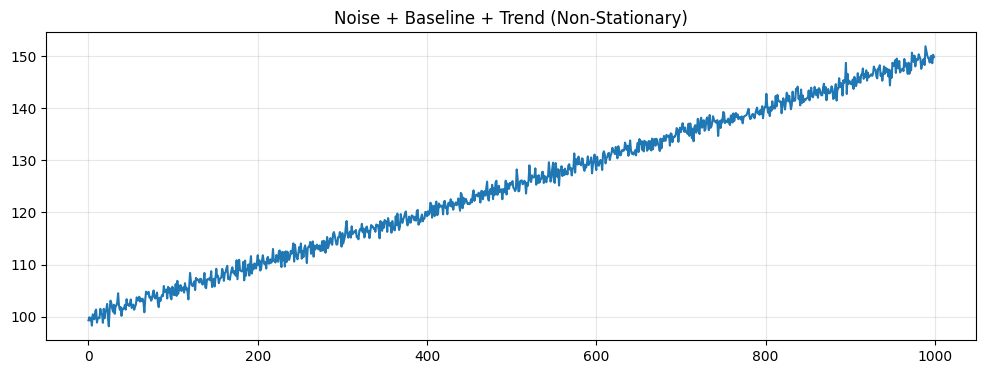

Trend Stationary: ❌ No
Variance Stationary: ❌ No
Seasonal Stationary: ❌ No


,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,❌ Non-stationary,-0.3909,0.9116,Deterministic trend detected - stationary after detrending,"H0: Unit root. ADF-c p=0.9116 >= 0.05, ADF-ct p=0.0000 < 0.05. Deterministic trend."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,❌ Non-stationary,5.1008,0.0100,Deterministic trend detected - stationary after detrending,"H0: Stationary. KPSS-c p=0.0100 <= 0.05, KPSS-ct p=0.1000 > 0.05. Deterministic trend."
2,Trend,Phillips-Perron (PP) Test,❌ Non-stationary,-0.5899,0.8732,Deterministic trend detected - stationary after detrending,"H0: Unit root. PP-c p=0.8732 >= 0.05, PP-ct p=0.0000 < 0.05. Deterministic trend."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-32.1303,0.0000,"Stationary with structural breaks: level shift at obs 743, trend shift at obs 305, level+trend shift at obs 743. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0007, ZA-ct p=0.0002 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,✅ Stationary,0.0976,0.9614,Constant variance across time,H0: Equal variances across segments. Levene p=0.9614 > 0.05. Fail to reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,✅ Stationary,0.1229,0.9890,Constant variance across time,H0: Equal variances across segments (assumes normality). Bartlett p=0.9890 > 0.05. Fail to reject H0.
6,Variance,White's Test for Heteroskedasticity,✅ Stationary,0.8175,0.6645,Constant variance across time,H0: Homoskedasticity. White p=0.6645 > 0.05. Fail to reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,984.8041,0.0000,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0000 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.9923,0.0000,"Seasonality detected (periods: 7, 12, 30, 52) - consider seasonal differencing (may trigger on trend/variance)",H0: No seasonality. Ljung-Box p=0.0000 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,✅ Stationary,0.1486,1.0000,No significant seasonal component detected,H0: No seasonality. F-stat p=1.0000 > 0.05. Fail to reject H0.


In [26]:
ts_trend = pd.Series(
    100 + 0.05 * np.arange(n) + np.random.normal(0, 1, n),
    index=pd.date_range('2020-01-01', periods=n, freq='D')
)
plot_ts(ts_trend.values, "Noise + Baseline + Trend (Non-Stationary)")

result = toolkit.detect(ts_trend, verbosity='detailed')
print(result.summary)
result.report(filepath='examples/case3_trend_report.md')

ADF, KPSS, PP correctly detect deterministic trend. ZA false positive (finds spurious breaks in smooth trend). ARCH fails due to trend-induced autocorrelation, not true volatility clustering. ACF detects trend as false seasonality - demonstrates cross-contamination between non-stationarity types.

### 1.4 Noise + Baseline + Seasonality (Non-Stationary)

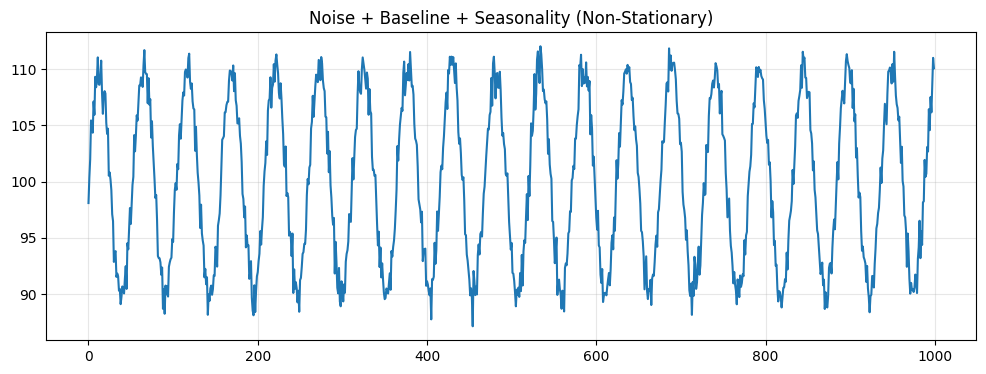

Trend Stationary: ✅ Yes
Variance Stationary: ❌ No
Seasonal Stationary: ❌ No


,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,✅ Stationary,-14.4895,0.0000,Stationary around constant mean,"H0: Unit root. ADF-c p=0.0000 < 0.05, ADF-ct p=0.0000 < 0.05. Reject H0."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,✅ Stationary,0.0099,0.1000,Stationary around constant mean,"H0: Stationary. KPSS-c p=0.1000 > 0.05, KPSS-ct p=0.1000 > 0.05. Fail to reject H0."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-6.5116,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-14.7602,0.0000,"Stationary with structural breaks: level shift at obs 721, trend shift at obs 264, level+trend shift at obs 721. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0010, ZA-ct p=0.0007 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,✅ Stationary,0.4526,0.7155,Constant variance across time,H0: Equal variances across segments. Levene p=0.7155 > 0.05. Fail to reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,✅ Stationary,0.3359,0.9531,Constant variance across time,H0: Equal variances across segments (assumes normality). Bartlett p=0.9531 > 0.05. Fail to reject H0.
6,Variance,White's Test for Heteroskedasticity,✅ Stationary,0.5885,0.7451,Constant variance across time,H0: Homoskedasticity. White p=0.7451 > 0.05. Fail to reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,962.2527,0.0000,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0000 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.9707,0.0000,Seasonality detected (periods: 52) - consider seasonal differencing (may trigger on trend/variance),H0: No seasonality. Ljung-Box p=0.0000 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,❌ Non-stationary,62.4157,0.0000,Significant seasonal component detected (period 52) - consider seasonal differencing,H0: No seasonality. F-stat p=0.0000 <= 0.05. Reject H0.


In [27]:
ts_seasonal = pd.Series(
    100 + 10 * np.sin(2 * np.pi * np.arange(n) / 52) + np.random.normal(0, 1, n),
    index=pd.date_range('2020-01-01', periods=n, freq='W')
)
plot_ts(ts_seasonal.values, "Noise + Baseline + Seasonality (Non-Stationary)")

result = toolkit.detect(ts_seasonal, verbosity='detailed')
print(result.summary)
result.report(filepath='examples/case4_seasonal_report.md')

ACF and STL correctly detect 52-week seasonality. ARCH fails due to seasonal autocorrelation.

### 1.5 Noise + Baseline + Changing Variance (Non-Stationary)

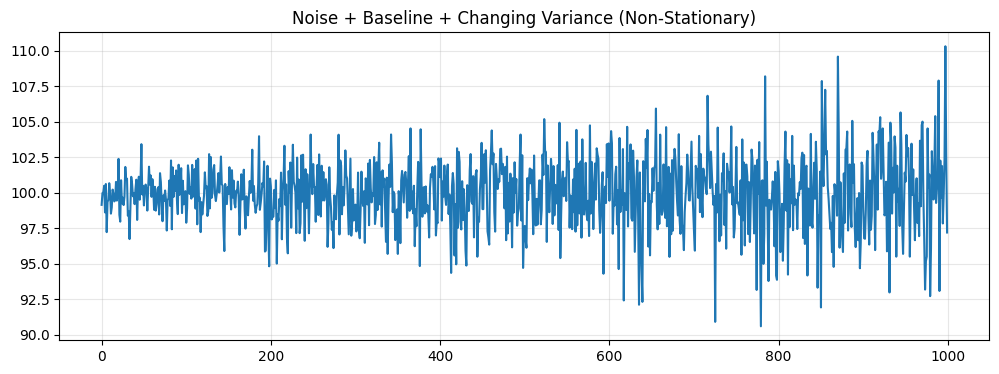

Trend Stationary: ✅ Yes
Variance Stationary: ❌ No
Seasonal Stationary: ✅ Yes


,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,✅ Stationary,-31.8853,0.0000,Stationary around constant mean,"H0: Unit root. ADF-c p=0.0000 < 0.05, ADF-ct p=0.0000 < 0.05. Reject H0."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,✅ Stationary,0.1248,0.1000,Stationary around constant mean,"H0: Stationary. KPSS-c p=0.1000 > 0.05, KPSS-ct p=0.1000 > 0.05. Fail to reject H0."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-31.9472,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-31.9575,0.0000,"Stationary with structural breaks: level shift at obs 848, trend shift at obs 835, level+trend shift at obs 777. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0007, ZA-ct p=0.0002 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,❌ Non-stationary,37.4542,0.0000,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments. Levene p=0.0000 <= 0.05. Reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,❌ Non-stationary,135.7226,0.0000,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments (assumes normality). Bartlett p=0.0000 <= 0.05. Reject H0.
6,Variance,White's Test for Heteroskedasticity,❌ Non-stationary,87.0758,0.0000,Time-dependent variance detected - consider Box-Cox or Yeo-Johnson transform,H0: Homoskedasticity. White p=0.0000 <= 0.05. Reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,✅ Stationary,11.1510,0.3459,"No volatility clustering detected (ARCH tests for clustered variance, not smooth changes)",H0: No ARCH effects. ARCH p=0.3459 > 0.05. Fail to reject H0.
8,Seasonal,ACF/PACF Peak Detection,✅ Stationary,0.0894,1.0000,No seasonal patterns detected,H0: No seasonality. Ljung-Box p=1.0000 >= 0.05. Fail to reject H0.
9,Seasonal,STL Decomposition,✅ Stationary,0.1473,1.0000,No significant seasonal component detected,H0: No seasonality. F-stat p=1.0000 > 0.05. Fail to reject H0.


In [28]:
variance = 1 + 0.01 * np.arange(n)
ts_hetero = pd.Series(
    100 + np.random.normal(0, np.sqrt(variance), n),
    index=pd.date_range('2020-01-01', periods=n, freq='D')
)
plot_ts(ts_hetero.values, "Noise + Baseline + Changing Variance (Non-Stationary)")

result = toolkit.detect(ts_hetero, verbosity='detailed')
print(result.summary)
result.report(filepath='examples/case5_variance_report.md')

Levene, Bartlett, White correctly detect growing variance. ARCH passes - validates it only detects clustered variance, not smooth changes.

### 1.6 Noise + Baseline + Clustered Variance (Non-Stationary)

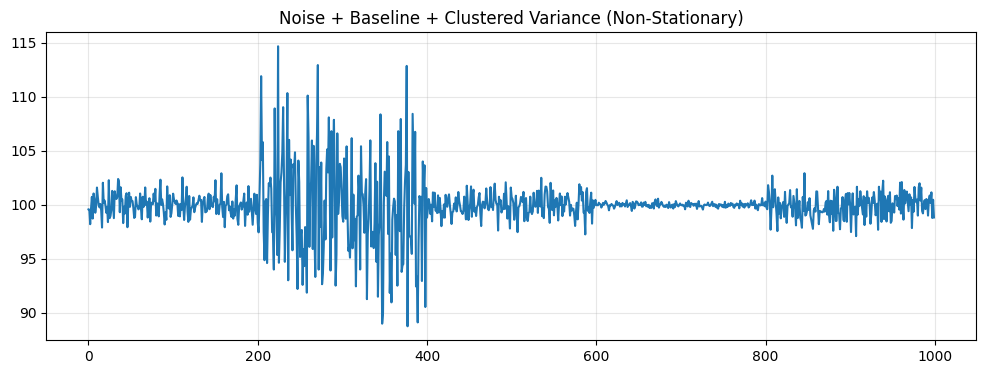

Trend Stationary: ✅ Yes
Variance Stationary: ❌ No
Seasonal Stationary: ❌ No


,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,✅ Stationary,-5.9922,0.0000,Stationary around constant mean,"H0: Unit root. ADF-c p=0.0000 < 0.05, ADF-ct p=0.0000 < 0.05. Reject H0."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,✅ Stationary,0.1188,0.1000,Stationary around constant mean,"H0: Stationary. KPSS-c p=0.1000 > 0.05, KPSS-ct p=0.1000 > 0.05. Fail to reject H0."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-31.4896,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-7.3292,0.0000,"Stationary with structural breaks: level shift at obs 306, trend shift at obs 359, level+trend shift at obs 306. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0031, ZA-ct p=0.0010 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,❌ Non-stationary,86.2640,0.0000,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments. Levene p=0.0000 <= 0.05. Reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,❌ Non-stationary,815.8958,0.0000,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments (assumes normality). Bartlett p=0.0000 <= 0.05. Reject H0.
6,Variance,White's Test for Heteroskedasticity,❌ Non-stationary,52.7225,0.0000,Time-dependent variance detected - consider Box-Cox or Yeo-Johnson transform,H0: Homoskedasticity. White p=0.0000 <= 0.05. Reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,29.1246,0.0012,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0012 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.1372,0.0000,"Seasonality detected (periods: 7, 12, 30, 52) - consider seasonal differencing (may trigger on trend/variance)",H0: No seasonality. Ljung-Box p=0.0000 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,✅ Stationary,0.2474,1.0000,No significant seasonal component detected,H0: No seasonality. F-stat p=1.0000 > 0.05. Fail to reject H0.


In [29]:
# Explicit volatility clustering (regime switches)
volatility = np.ones(n)
volatility[200:400] = 5  # High volatility period
volatility[600:800] = 0.2  # Low volatility period

ts_clustered = pd.Series(
    100 + np.random.normal(0, volatility, n),
    index=pd.date_range('2020-01-01', periods=n, freq='D')
)
plot_ts(ts_clustered.values, "Noise + Baseline + Clustered Variance (Non-Stationary)")

result = toolkit.detect(ts_clustered, verbosity='detailed')
print(result.summary)
result.report(filepath='examples/case6_clustered_report.md')

All variance tests correctly detect regime-switch volatility clustering. ARCH successfully identifies clustered variance. ACF false positive (detects variance as seasonality) - demonstrates test limitations.

## Part 2: A Simple Workflow

Now let's see how the toolkit guides preprocessing decisions. We'll create a time series with trend and 52-week seasonality - the kind of pattern you'd see in weekly business data. The workflow is straightforward: test it, transform it, test it again.

The initial test should identify both the trend and seasonality. We'll also see the ARCH test fail, but that's a false alarm - it's responding to the autocorrelation from trend and seasonality, not actual volatility clustering. This is one of those limitations we discovered in Part 1.

After differencing to remove both trend and seasonality, we retest. The trend and seasonality should be gone, but here's where it gets interesting: variance tests that passed before now fail. We didn't add any heteroscedasticity to the original data, yet it appeared after differencing. This is the toolkit's value - it reveals that transformations don't just solve problems, they can create new ones. Whether this new variance issue matters depends on your use case, but at least now you know it's there.

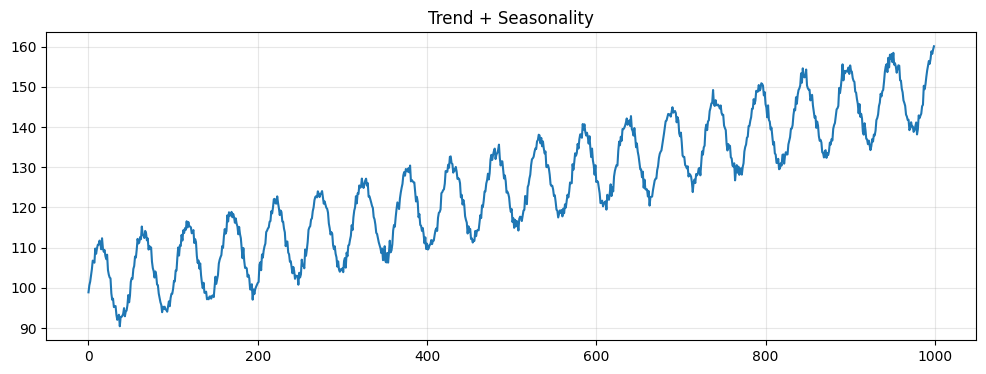

In [30]:
# Generate data with trend and seasonality
ts_complex = pd.Series(
    100 + 0.05 * np.arange(n) + 10 * np.sin(2 * np.pi * np.arange(n) / 52) + np.random.normal(0, 1, n),
    index=pd.date_range('2020-01-01', periods=n, freq='W')
)
plot_ts(ts_complex.values, "Trend + Seasonality")

### Step 1: Initial Testing

In [48]:
result_before = toolkit.detect(ts_complex, verbosity='detailed')
result_before.report()

,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,❌ Non-stationary,-0.6090,0.8689,Deterministic trend detected - stationary after detrending,"H0: Unit root. ADF-c p=0.8689 >= 0.05, ADF-ct p=0.0000 < 0.05. Deterministic trend."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,❌ Non-stationary,4.4629,0.0100,Deterministic trend detected - stationary after detrending,"H0: Stationary. KPSS-c p=0.0100 <= 0.05, KPSS-ct p=0.1000 > 0.05. Deterministic trend."
2,Trend,Phillips-Perron (PP) Test,❌ Non-stationary,-2.7384,0.0676,Deterministic trend detected - stationary after detrending,"H0: Unit root. PP-c p=0.0676 >= 0.05, PP-ct p=0.0000 < 0.05. Deterministic trend."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-16.0353,0.0000,"Stationary with structural breaks: level shift at obs 407, trend shift at obs 849, level+trend shift at obs 824. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0010, ZA-ct p=0.0007 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,✅ Stationary,0.8956,0.4429,Constant variance across time,H0: Equal variances across segments. Levene p=0.4429 > 0.05. Fail to reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,✅ Stationary,1.9897,0.5745,Constant variance across time,H0: Equal variances across segments (assumes normality). Bartlett p=0.5745 > 0.05. Fail to reject H0.
6,Variance,White's Test for Heteroskedasticity,✅ Stationary,0.1837,0.9122,Constant variance across time,H0: Homoskedasticity. White p=0.9122 > 0.05. Fail to reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,982.2571,0.0000,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0000 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.9907,0.0000,Seasonality detected (periods: 52) - consider seasonal differencing (may trigger on trend/variance),H0: No seasonality. Ljung-Box p=0.0000 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,❌ Non-stationary,59.1103,0.0000,Significant seasonal component detected (period 52) - consider seasonal differencing,H0: No seasonality. F-stat p=0.0000 <= 0.05. Reject H0.


The toolkit correctly identifies the non-stationarity. ADF, KPSS, and PP flag the deterministic trend. ZA shows a false positive (finds spurious breaks in smooth trends). Variance tests correctly pass except ARCH, which fails due to trend/seasonality-induced autocorrelation rather than true volatility clustering. Both seasonal tests correctly detect the 52-week pattern. These results validate the toolkit's detection capabilities.

### Step 2: Apply Transformations

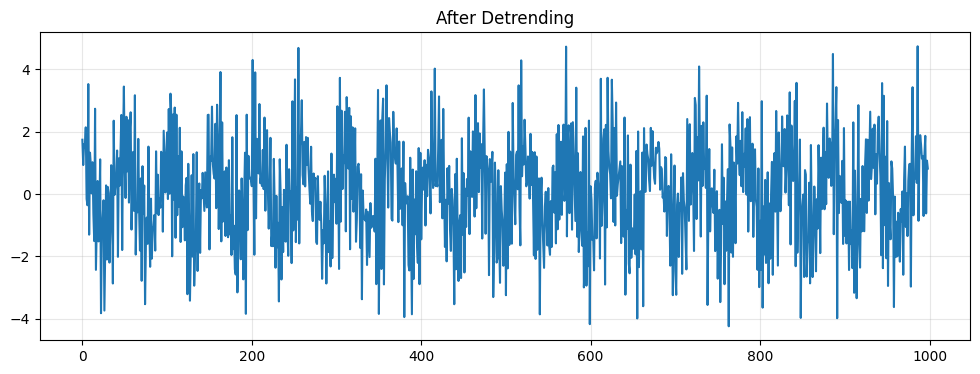

In [49]:
# Detrend
ts_detrended = ts_complex.diff().dropna()
plot_ts(ts_detrended.values, "After Detrending")

### Step 3: Retest

In [50]:
result_after = toolkit.detect(ts_detrended, verbosity='detailed')
result_after.report()

,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,✅ Stationary,-17.0140,0.0000,Stationary around constant mean,"H0: Unit root. ADF-c p=0.0000 < 0.05, ADF-ct p=0.0000 < 0.05. Reject H0."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,✅ Stationary,0.0094,0.1000,Stationary around constant mean,"H0: Stationary. KPSS-c p=0.1000 > 0.05, KPSS-ct p=0.1000 > 0.05. Fail to reject H0."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-40.4184,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-17.0037,0.0000,"Stationary with structural breaks: level shift at obs 737, trend shift at obs 820, level+trend shift at obs 796. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0010, ZA-ct p=0.0007 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,✅ Stationary,0.3019,0.8241,Constant variance across time,H0: Equal variances across segments. Levene p=0.8241 > 0.05. Fail to reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,✅ Stationary,0.6646,0.8815,Constant variance across time,H0: Equal variances across segments (assumes normality). Bartlett p=0.8815 > 0.05. Fail to reject H0.
6,Variance,White's Test for Heteroskedasticity,✅ Stationary,0.3870,0.8241,Constant variance across time,H0: Homoskedasticity. White p=0.8241 > 0.05. Fail to reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,20.6880,0.0234,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0234 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.2717,0.0000,Seasonality detected (periods: 52) - consider seasonal differencing (may trigger on trend/variance),H0: No seasonality. Ljung-Box p=0.0000 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,✅ Stationary,0.6043,1.0000,No significant seasonal component detected,H0: No seasonality. F-stat p=1.0000 > 0.05. Fail to reject H0.


The transformations successfully addressed the trend - all trend tests now pass. STL confirm the seasonal pattern is eliminated, though ACF still flags residual autocorrelation albeit with smaller test statistic 0.99 prior vs 0.27 now. Variance tests continue to pass except ARCH likely due to its tendency to trigger on temporal patterns.

### Step 4: Would Seasonal Differencing Work ?

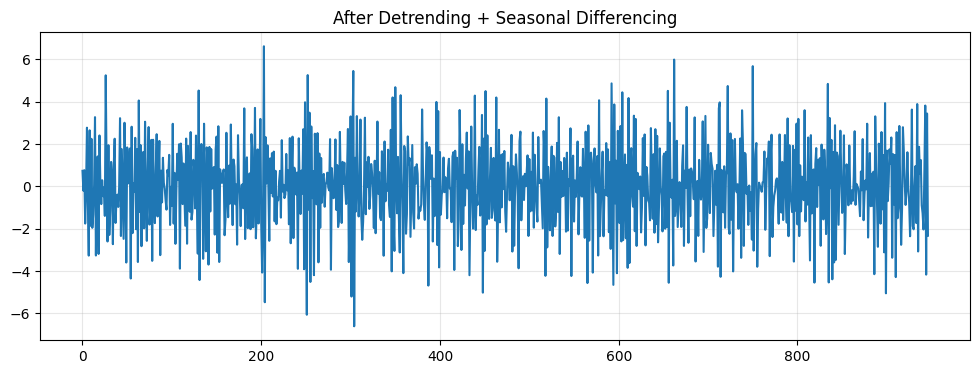

In [51]:
# Seasonal differencing
ts_transformed = ts_detrended.diff(52).dropna()
plot_ts(ts_transformed.values, "After Detrending + Seasonal Differencing")

In [52]:
result_after = toolkit.detect(ts_transformed, verbosity='detailed')
result_after.report()

,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,✅ Stationary,-12.4676,0.0000,Stationary around constant mean,"H0: Unit root. ADF-c p=0.0000 < 0.05, ADF-ct p=0.0000 < 0.05. Reject H0."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,✅ Stationary,0.0397,0.1000,Stationary around constant mean,"H0: Stationary. KPSS-c p=0.1000 > 0.05, KPSS-ct p=0.1000 > 0.05. Fail to reject H0."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-154.6462,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-12.5058,0.0000,"Stationary with structural breaks: level shift at obs 447, trend shift at obs 804, level+trend shift at obs 767. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0013, ZA-ct p=0.0008 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,✅ Stationary,0.3113,0.8172,Constant variance across time,H0: Equal variances across segments. Levene p=0.8172 > 0.05. Fail to reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,✅ Stationary,1.9347,0.5861,Constant variance across time,H0: Equal variances across segments (assumes normality). Bartlett p=0.5861 > 0.05. Fail to reject H0.
6,Variance,White's Test for Heteroskedasticity,✅ Stationary,0.1408,0.9320,Constant variance across time,H0: Homoskedasticity. White p=0.9320 > 0.05. Fail to reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,61.3137,0.0000,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0000 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.5111,0.0000,Seasonality detected (periods: 52) - consider seasonal differencing (may trigger on trend/variance),H0: No seasonality. Ljung-Box p=0.0000 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,✅ Stationary,0.0249,1.0000,No significant seasonal component detected,H0: No seasonality. F-stat p=1.0000 > 0.05. Fail to reject H0.


After seasonal differencing, the ACF outcome got worse indicating just conventional 52 lag differencing won't work to handle it. Perhaps, more detailed analysis needed. But that's besides the point that the toolkit does its job in letting you know what's happenning.

## Part 3: When Things Get Complicated

Real data rarely has just one problem. This series combines trend, seasonality, and heteroscedasticity - all three at once. Now the question isn't just "what transformations do I need?" but "in what order?"

We'll follow the recommended sequence: stabilize variance first, then remove trend, then handle seasonality. But here's what makes this interesting - we test after every single step. Not because we're being thorough, but because transformations interact in ways you can't predict.

Watch what happens: Box-Cox stabilizes the variance nicely. Then we difference to remove the trend, and suddenly all the variance tests fail again. The stabilization didn't survive the differencing. Meanwhile, ACF keeps flagging seasonality even after STL say it's gone. Is there really seasonality left, or is ACF just picking up the variance issues? The only way to know is to test at each step and see what's actually happening versus what you expected to happen.

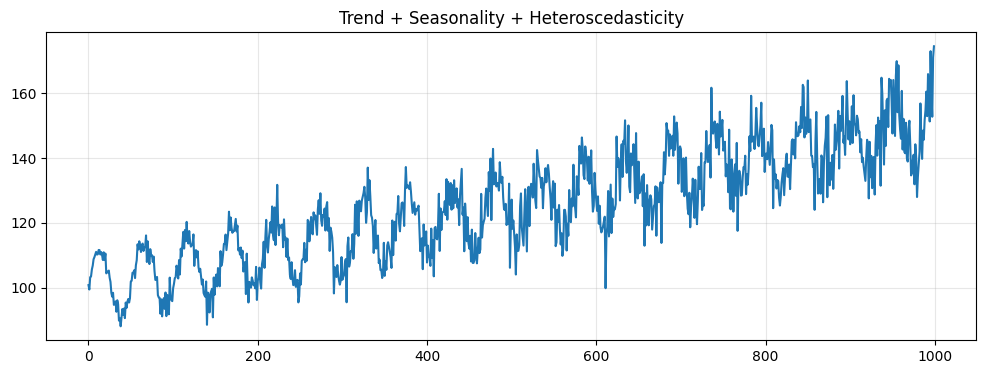

In [53]:
# Generate complex data
variance = 1 + 0.05 * np.arange(n)
ts_full = pd.Series(
    100 + 0.05 * np.arange(n) + 10 * np.sin(2 * np.pi * np.arange(n) / 52) + np.random.normal(0, np.sqrt(variance), n),
    index=pd.date_range('2020-01-01', periods=n, freq='W')
)
plot_ts(ts_full.values, "Trend + Seasonality + Heteroscedasticity")

In [54]:
# Test
result_full_before = toolkit.detect(ts_full, verbosity='detailed')
result_full_before.report()

,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,❌ Non-stationary,-1.9483,0.3097,Deterministic trend detected - stationary after detrending,"H0: Unit root. ADF-c p=0.3097 >= 0.05, ADF-ct p=0.0000 < 0.05. Deterministic trend."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,❌ Non-stationary,4.4473,0.0100,Deterministic trend detected - stationary after detrending,"H0: Stationary. KPSS-c p=0.0100 <= 0.05, KPSS-ct p=0.1000 > 0.05. Deterministic trend."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-7.5072,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-13.5080,0.0000,"Stationary with structural breaks: level shift at obs 443, trend shift at obs 612, level+trend shift at obs 443. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0011, ZA-ct p=0.0008 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,❌ Non-stationary,4.1204,0.0064,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments. Levene p=0.0064 <= 0.05. Reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,❌ Non-stationary,18.9937,0.0003,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments (assumes normality). Bartlett p=0.0003 <= 0.05. Reject H0.
6,Variance,White's Test for Heteroskedasticity,❌ Non-stationary,16.7963,0.0002,Time-dependent variance detected - consider Box-Cox or Yeo-Johnson transform,H0: Homoskedasticity. White p=0.0002 <= 0.05. Reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,848.2545,0.0000,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0000 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.8948,0.0000,Seasonality detected (periods: 52) - consider seasonal differencing (may trigger on trend/variance),H0: No seasonality. Ljung-Box p=0.0000 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,❌ Non-stationary,2.6187,0.0000,Significant seasonal component detected (period 52) - consider seasonal differencing,H0: No seasonality. F-stat p=0.0000 <= 0.05. Reject H0.


This complex series combines all three non-stationarity types. The trend tests show interesting behavior: ADF and KPSS correctly flag the deterministic trend, while PP unexpectedly passes. PP's non-parametric variance correction (Newey-West estimator) appears to break down with long-period seasonal autocorrelation (lag 52) plus growing variance. ZA finds spurious structural breaks in the smooth trend.

Variance tests: Sometimes, Levene barely passes (such as with p=0.059), but mostly all variance tests detect the 50-fold variance growth. ARCH fails, likely from trend/seasonality autocorrelation rather than true clustering.

Seasonality: Both ACF and STL detect the 52-period cycle, confirming the presence of deterministic (fixed, repeating) seasonal patterns.

The toolkit reveals each layer of non-stationarity and how different tests respond to combined effects.

### Step 1: Stabilize Variance (Box-Cox)

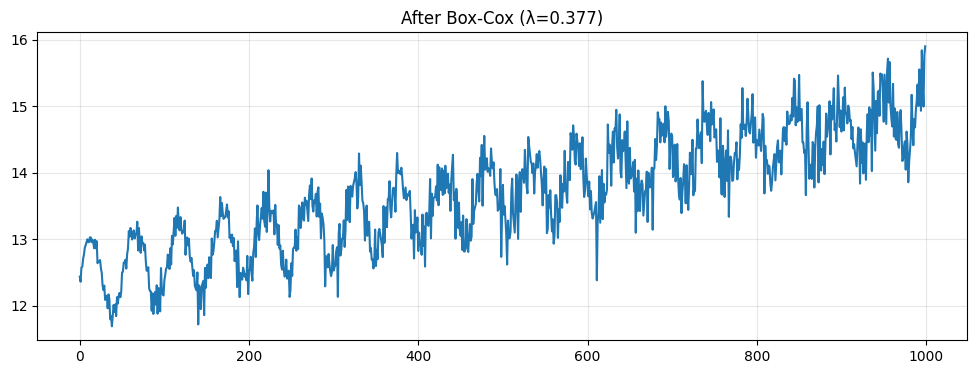

,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,❌ Non-stationary,-1.9987,0.2871,Deterministic trend detected - stationary after detrending,"H0: Unit root. ADF-c p=0.2871 >= 0.05, ADF-ct p=0.0000 < 0.05. Deterministic trend."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,❌ Non-stationary,4.4279,0.0100,Deterministic trend detected - stationary after detrending,"H0: Stationary. KPSS-c p=0.0100 <= 0.05, KPSS-ct p=0.1000 > 0.05. Deterministic trend."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-7.2638,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-13.4272,0.0000,"Stationary with structural breaks: level shift at obs 164, trend shift at obs 278, level+trend shift at obs 443. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0011, ZA-ct p=0.0008 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,✅ Stationary,1.2255,0.2992,Constant variance across time,H0: Equal variances across segments. Levene p=0.2992 > 0.05. Fail to reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,✅ Stationary,4.5495,0.2079,Constant variance across time,H0: Equal variances across segments (assumes normality). Bartlett p=0.2079 > 0.05. Fail to reject H0.
6,Variance,White's Test for Heteroskedasticity,✅ Stationary,0.3405,0.8435,Constant variance across time,H0: Homoskedasticity. White p=0.8435 > 0.05. Fail to reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,862.4914,0.0000,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0000 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.9003,0.0000,Seasonality detected (periods: 52) - consider seasonal differencing (may trigger on trend/variance),H0: No seasonality. Ljung-Box p=0.0000 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,❌ Non-stationary,2.8080,0.0000,Significant seasonal component detected (period 52) - consider seasonal differencing,H0: No seasonality. F-stat p=0.0000 <= 0.05. Reject H0.


In [55]:
from scipy.stats import boxcox
ts_boxcox, lambda_param = boxcox(ts_full)
ts_boxcox = pd.Series(ts_boxcox, index=ts_full.index)
plot_ts(ts_boxcox.values, f"After Box-Cox (λ={lambda_param:.3f})")

result_step1 = toolkit.detect(ts_boxcox, verbosity='detailed')
result_step1.report()

Box-Cox successfully stabilized the variance - Levene, Bartlett, and White all pass. The ARCH test still fails, but as its notes indicate, this can occur due to autocorrelation from trend and seasonality. The trend and seasonal patterns remain unchanged, as expected after variance-only transformation.

### Step 2: Remove Trend (Differencing)

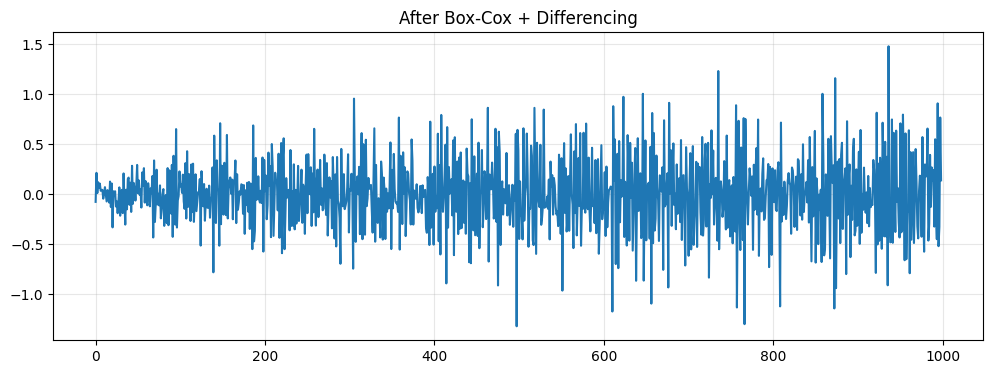

,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,✅ Stationary,-10.6874,0.0000,Stationary around constant mean,"H0: Unit root. ADF-c p=0.0000 < 0.05, ADF-ct p=0.0000 < 0.05. Reject H0."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,✅ Stationary,0.1370,0.1000,Stationary around constant mean,"H0: Stationary. KPSS-c p=0.1000 > 0.05, KPSS-ct p=0.1000 > 0.05. Fail to reject H0."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-64.3445,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-10.6992,0.0000,"Stationary with structural breaks: level shift at obs 440, trend shift at obs 818, level+trend shift at obs 807. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0017, ZA-ct p=0.0009 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,❌ Non-stationary,24.2371,0.0000,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments. Levene p=0.0000 <= 0.05. Reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,❌ Non-stationary,89.4104,0.0000,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments (assumes normality). Bartlett p=0.0000 <= 0.05. Reject H0.
6,Variance,White's Test for Heteroskedasticity,❌ Non-stationary,59.7366,0.0000,Time-dependent variance detected - consider Box-Cox or Yeo-Johnson transform,H0: Homoskedasticity. White p=0.0000 <= 0.05. Reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,106.9324,0.0000,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0000 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.4837,0.0000,Seasonality detected (periods: 52) - consider seasonal differencing (may trigger on trend/variance),H0: No seasonality. Ljung-Box p=0.0000 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,✅ Stationary,0.2403,1.0000,No significant seasonal component detected,H0: No seasonality. F-stat p=1.0000 > 0.05. Fail to reject H0.


In [56]:
ts_diff = ts_boxcox.diff().dropna()
plot_ts(ts_diff.values, "After Box-Cox + Differencing")

result_step2 = toolkit.detect(ts_diff, verbosity='detailed')
result_step2.report()

Differencing removed the trend - all trend tests now pass. However, all variance tests now fail. The toolkit reveals that the variance stabilization from Step 1 didn't survive the differencing transformation. STL pass for seasonality, but ACF still fails. Given ACF's note that it "may trigger on trend/variance," and the clear variance issues, the ACF signal is likely variance-related rather than true seasonality.

### Step 3: Remove Seasonality (Seasonal Differencing)

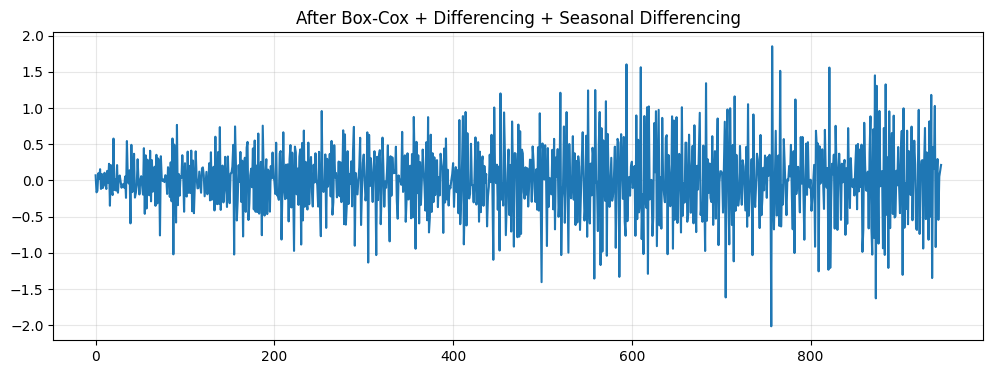

,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,✅ Stationary,-11.6336,0.0000,Stationary around constant mean,"H0: Unit root. ADF-c p=0.0000 < 0.05, ADF-ct p=0.0000 < 0.05. Reject H0."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,✅ Stationary,0.1494,0.1000,Stationary around constant mean,"H0: Stationary. KPSS-c p=0.1000 > 0.05, KPSS-ct p=0.1000 > 0.05. Fail to reject H0."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-158.3697,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-11.6565,0.0000,"Stationary with structural breaks: level shift at obs 751, trend shift at obs 746, level+trend shift at obs 612. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0015, ZA-ct p=0.0008 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,❌ Non-stationary,25.5875,0.0000,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments. Levene p=0.0000 <= 0.05. Reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,❌ Non-stationary,100.2125,0.0000,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments (assumes normality). Bartlett p=0.0000 <= 0.05. Reject H0.
6,Variance,White's Test for Heteroskedasticity,❌ Non-stationary,67.9330,0.0000,Time-dependent variance detected - consider Box-Cox or Yeo-Johnson transform,H0: Homoskedasticity. White p=0.0000 <= 0.05. Reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,122.7720,0.0000,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0000 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.5145,0.0000,Seasonality detected (periods: 52) - consider seasonal differencing (may trigger on trend/variance),H0: No seasonality. Ljung-Box p=0.0000 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,✅ Stationary,0.0182,1.0000,No significant seasonal component detected,H0: No seasonality. F-stat p=1.0000 > 0.05. Fail to reject H0.


In [57]:
ts_full_transformed = ts_diff.diff(52).dropna()
plot_ts(ts_full_transformed.values, "After Box-Cox + Differencing + Seasonal Differencing")

result_step3 = toolkit.detect(ts_full_transformed, verbosity='detailed')
result_step3.report()

Seasonal differencing applied, but the results are largely unchanged from Step 2. Variance tests still fail, ACF still fails, while STL still passes. This confirms what we suspected after Step 2: the ACF signal was variance-related, not true seasonality. The toolkit helped us avoid unnecessary transformation by revealing the true source of the ACF failure through iterative testing.

## Part 4: Real Data Doesn't Read the Textbook

Everything we've done so far used synthetic data where we controlled exactly what non-stationarity existed. Real data is messier. This Walmart sales series shows mixed signals right from the start - KPSS says there's a trend, but ADF, PP, and ZA all say the series is stationary. Who's right? Probably all of them - the trend is weak enough that it's borderline.

But here's the real lesson: the same transformations we used in Part 3 produce completely different results here. In Part 3, Box-Cox stabilized variance but differencing destabilized it. Here? Box-Cox helps a little, differencing helps more, then seasonal differencing reverses some of the gains. Same transformations, different data, different outcomes.

This is why you can't just follow a recipe. You can't assume "Box-Cox then difference" will always work the same way. The toolkit lets you see what actually happened with your specific data, so you can decide whether to keep going or try a different approach.

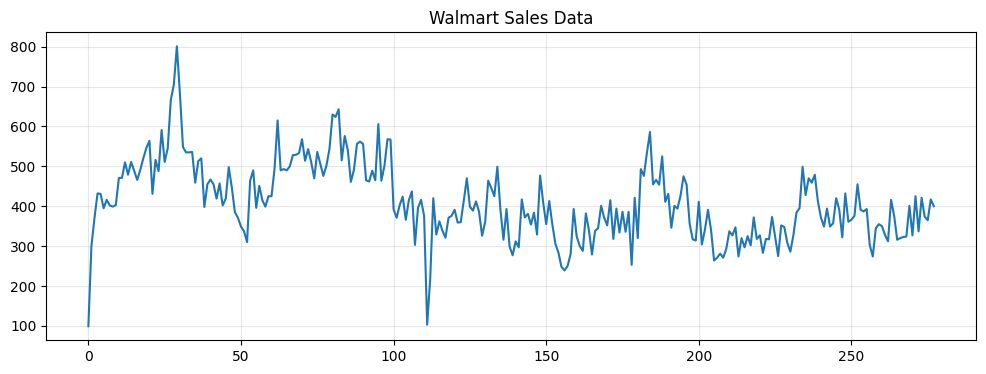

In [59]:
# Load data
df = pd.read_csv('examples/walmartSales_FOODS_3_586_TX_1_evaluation.csv')
df['date'] = pd.to_datetime(df['date'])
ts_walmart = pd.Series(df['value'].values, index=pd.DatetimeIndex(df['date'], freq='W-MON'))
plot_ts(ts_walmart.values, "Walmart Sales Data")

In [60]:
# Test
result_walmart = toolkit.detect(ts_walmart, verbosity='detailed')
print(result_walmart.summary)
result_walmart.report(filepath='examples/walmart_report.md')

Trend Stationary: ❌ No
Variance Stationary: ❌ No
Seasonal Stationary: ❌ No


,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,✅ Stationary,-3.2863,0.0155,Stationary around constant mean,"H0: Unit root. ADF-c p=0.0155 < 0.05, ADF-ct p=0.0039 < 0.05. Reject H0."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,❌ Non-stationary,1.1964,0.0100,Deterministic trend detected - stationary after detrending,"H0: Stationary. KPSS-c p=0.0100 <= 0.05, KPSS-ct p=0.0951 > 0.05. Deterministic trend."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-7.8514,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-5.5103,0.0040,"Stationary with structural breaks: level shift at obs 99, trend shift at obs 155, level+trend shift at obs 99. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0040, ZA-t p=0.0285, ZA-ct p=0.0157 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,❌ Non-stationary,5.7629,0.0008,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments. Levene p=0.0008 <= 0.05. Reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,❌ Non-stationary,30.8232,0.0000,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments (assumes normality). Bartlett p=0.0000 <= 0.05. Reject H0.
6,Variance,White's Test for Heteroskedasticity,❌ Non-stationary,10.8138,0.0045,Time-dependent variance detected - consider Box-Cox or Yeo-Johnson transform,H0: Homoskedasticity. White p=0.0045 <= 0.05. Reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,173.6824,0.0000,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0000 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.7508,0.0000,Seasonality detected (periods: 52) - consider seasonal differencing (may trigger on trend/variance),H0: No seasonality. Ljung-Box p=0.0000 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,❌ Non-stationary,2.3183,0.0000,Significant seasonal component detected (period 52) - consider seasonal differencing,H0: No seasonality. F-stat p=0.0000 <= 0.05. Reject H0.


The Walmart sales data presents an interesting case of mixed signals. For trend, KPSS flags a deterministic trend while ADF, PP, and ZA all pass. This disagreement suggests the trend is relatively weak or the series is borderline stationary around a constant mean. The majority of tests indicate stationarity, though the KPSS result suggests some trend-like behavior may be present.

The variance tests tell a clear story - all four tests fail, indicating heteroscedasticity. The variance changes across time segments (Levene, Bartlett), shows time-dependent patterns (White), and exhibits clustering (ARCH, though likely due to autocorrelation from trend/seasonality). Box-Cox transformation would address this.

For seasonality, both ACF and STL detect the strong 52-week pattern, confirming the presence of deterministic seasonal patterns.

This real-world data demonstrates how multiple forms of non-stationarity coexist, and how the toolkit's comprehensive testing reveals each layer. The next step would be to apply transformations iteratively and retest to see how each transformation affects the overall stationarity profile.

### Step 1: Stabilize Variance (Box-Cox)

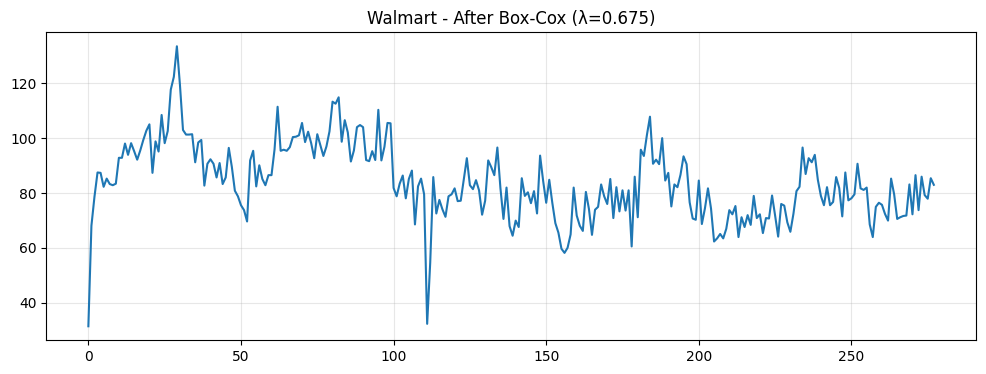

,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,✅ Stationary,-3.3206,0.0140,Stationary around constant mean,"H0: Unit root. ADF-c p=0.0140 < 0.05, ADF-ct p=0.0035 < 0.05. Reject H0."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,❌ Non-stationary,1.1708,0.0100,Deterministic trend detected - stationary after detrending,"H0: Stationary. KPSS-c p=0.0100 <= 0.05, KPSS-ct p=0.0932 > 0.05. Deterministic trend."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-8.4822,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-5.5447,0.0036,"Stationary with structural breaks: level shift at obs 99, trend shift at obs 155, level+trend shift at obs 99. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0036, ZA-t p=0.0245, ZA-ct p=0.0142 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,❌ Non-stationary,4.4248,0.0047,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments. Levene p=0.0047 <= 0.05. Reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,❌ Non-stationary,27.2799,0.0000,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments (assumes normality). Bartlett p=0.0000 <= 0.05. Reject H0.
6,Variance,White's Test for Heteroskedasticity,❌ Non-stationary,7.6245,0.0221,Time-dependent variance detected - consider Box-Cox or Yeo-Johnson transform,H0: Homoskedasticity. White p=0.0221 <= 0.05. Reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,172.4148,0.0000,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0000 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.7297,0.0000,Seasonality detected (periods: 52) - consider seasonal differencing (may trigger on trend/variance),H0: No seasonality. Ljung-Box p=0.0000 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,❌ Non-stationary,2.1488,0.0000,Significant seasonal component detected (period 52) - consider seasonal differencing,H0: No seasonality. F-stat p=0.0000 <= 0.05. Reject H0.


In [61]:
from scipy.stats import boxcox
ts_walmart_boxcox, lambda_walmart = boxcox(ts_walmart)
ts_walmart_boxcox = pd.Series(ts_walmart_boxcox, index=ts_walmart.index)
plot_ts(ts_walmart_boxcox.values, f"Walmart - After Box-Cox (λ={lambda_walmart:.3f})")

result_walmart_step1 = toolkit.detect(ts_walmart_boxcox, verbosity='detailed')
result_walmart_step1.report()

Box-Cox reduced but didn't eliminate the variance non-stationarity. The p-values improved (Levene 0.0047 vs 0.0008, White 0.0221 vs 0.0045), but all variance tests still fail. This shows Box-Cox helped but the heteroscedasticity persists. The trend and seasonal patterns remain unchanged, as expected.

### Step 2: Remove Trend (Differencing)

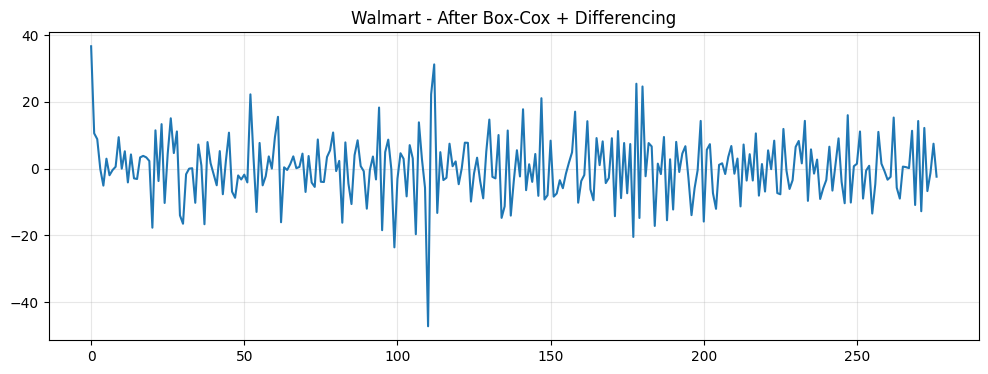

,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,✅ Stationary,-9.6556,0.0000,Stationary around constant mean,"H0: Unit root. ADF-c p=0.0000 < 0.05, ADF-ct p=0.0000 < 0.05. Reject H0."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,✅ Stationary,0.1829,0.1000,Stationary around constant mean,"H0: Stationary. KPSS-c p=0.1000 > 0.05, KPSS-ct p=0.1000 > 0.05. Fail to reject H0."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-30.6166,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-9.7740,0.0000,"Stationary with structural breaks: level shift at obs 156, trend shift at obs 41, level+trend shift at obs 51. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0000, ZA-t p=0.0019, ZA-ct p=0.0009 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,✅ Stationary,1.7370,0.1597,Constant variance across time,H0: Equal variances across segments. Levene p=0.1597 > 0.05. Fail to reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,❌ Non-stationary,10.7914,0.0129,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments (assumes normality). Bartlett p=0.0129 <= 0.05. Reject H0.
6,Variance,White's Test for Heteroskedasticity,✅ Stationary,2.1175,0.3469,Constant variance across time,H0: Homoskedasticity. White p=0.3469 > 0.05. Fail to reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,21.4123,0.0184,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0184 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.2904,0.0003,Seasonality detected (periods: 52) - consider seasonal differencing (may trigger on trend/variance),H0: No seasonality. Ljung-Box p=0.0003 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,✅ Stationary,0.7440,0.9929,No significant seasonal component detected,H0: No seasonality. F-stat p=0.9929 > 0.05. Fail to reject H0.


In [62]:
ts_walmart_diff = ts_walmart_boxcox.diff().dropna()
plot_ts(ts_walmart_diff.values, "Walmart - After Box-Cox + Differencing")

result_walmart_step2 = toolkit.detect(ts_walmart_diff, verbosity='detailed')
result_walmart_step2.report()

Differencing removed the trend and unexpectedly improved variance stationarity - Levene and White now pass, though Bartlett and ARCH still fail. This contrasts with Part 3, where differencing worsened variance. The difference: Part 3 had synthetic growing variance that Box-Cox stabilized but differencing destabilized; here, real-world heteroscedasticity responds differently to the same transformations.

For seasonality, STL now passes, but ACF still detects patterns. Given ACF's note about triggering on variance, and with Bartlett/ARCH still failing, the ACF signal is likely variance-related rather than true seasonality. This demonstrates the toolkit's value - revealing how transformations affect different forms of non-stationarity in unpredictable ways, enabling informed decisions about whether additional steps are needed.

### Step 3: Remove Seasonality (Seasonal Differencing)

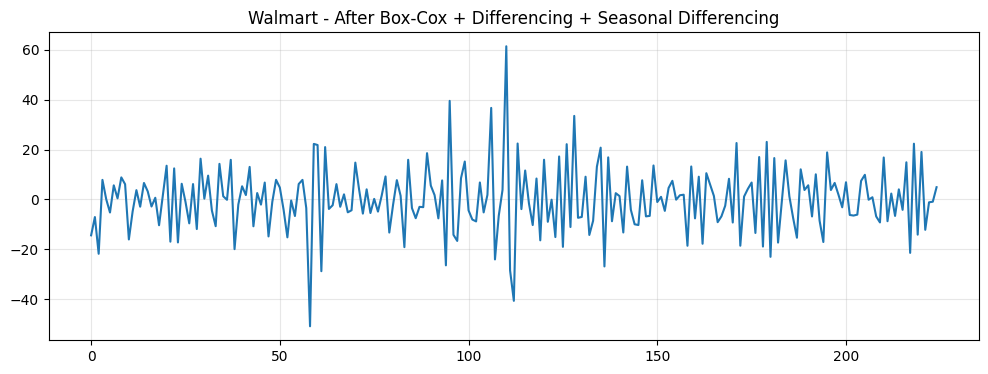

,Test Type,Test,Result,Statistic,P-value,Note,Interpretation
0,Trend,Augmented Dickey-Fuller (ADF) Test,✅ Stationary,-5.2695,0.0000,Stationary around constant mean,"H0: Unit root. ADF-c p=0.0000 < 0.05, ADF-ct p=0.0000 < 0.05. Reject H0."
1,Trend,Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test,✅ Stationary,0.2918,0.1000,Stationary around constant mean,"H0: Stationary. KPSS-c p=0.1000 > 0.05, KPSS-ct p=0.0939 > 0.05. Fail to reject H0."
2,Trend,Phillips-Perron (PP) Test,✅ Stationary,-37.6395,0.0000,Stationary around constant mean,"H0: Unit root. PP-c p=0.0000 < 0.05, PP-ct p=0.0000 < 0.05. Reject H0."
3,Trend,Zivot-Andrews Test for Structural Breaks,✅ Stationary,-5.7648,0.0014,"Stationary with structural breaks: level shift at obs 140, trend shift at obs 111, level+trend shift at obs 140. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.","H0: Unit root with no break. ZA-c p=0.0014, ZA-t p=0.0050, ZA-ct p=0.0051 < 0.05. Reject H0 - stationary."
4,Variance,Levene's Test for Variance Homogeneity,✅ Stationary,2.3456,0.0738,Constant variance across time,H0: Equal variances across segments. Levene p=0.0738 > 0.05. Fail to reject H0.
5,Variance,Bartlett's Test for Variance Homogeneity,❌ Non-stationary,20.4189,0.0001,Variance changes detected - consider Box-Cox or Yeo-Johnson transform,H0: Equal variances across segments (assumes normality). Bartlett p=0.0001 <= 0.05. Reject H0.
6,Variance,White's Test for Heteroskedasticity,❌ Non-stationary,6.2282,0.0444,Time-dependent variance detected - consider Box-Cox or Yeo-Johnson transform,H0: Homoskedasticity. White p=0.0444 <= 0.05. Reject H0.
7,Variance,ARCH Test for Conditional Heteroskedasticity,❌ Non-stationary,18.5884,0.0458,Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present),H0: No ARCH effects. ARCH p=0.0458 <= 0.05. Reject H0.
8,Seasonal,ACF/PACF Peak Detection,❌ Non-stationary,0.4514,0.0000,Seasonality detected (periods: 52) - consider seasonal differencing (may trigger on trend/variance),H0: No seasonality. Ljung-Box p=0.0000 < 0.05. Reject H0.
9,Seasonal,STL Decomposition,✅ Stationary,0.1897,1.0000,No significant seasonal component detected,H0: No seasonality. F-stat p=1.0000 > 0.05. Fail to reject H0.


In [22]:
ts_walmart_seasonal = ts_walmart_diff.diff(52).dropna()
plot_ts(ts_walmart_seasonal.values, "Walmart - After Box-Cox + Differencing + Seasonal Differencing")

result_walmart_step3 = toolkit.detect(ts_walmart_seasonal, verbosity='detailed')
result_walmart_step3.report()

Seasonal differencing worsened variance stationarity - White now fails again (was passing), and Levene is borderline (p=0.0738). Only Levene passes, while Bartlett, White, and ARCH all fail. For seasonality, STL still passes, but ACF still fails. The ACF signal persists despite STL showing no seasonal component, confirming it's detecting autocorrelation from the variance issues rather than true seasonality.

Box-Cox helped variance, differencing helped more, but seasonal differencing reversed some gains. Same transformations as Part 3, completely different trajectory.

## Conclusion

The toolkit's value isn't in prescribing solutions - it's in revealing what's actually there. Single-test approaches miss the nuances we've seen throughout this notebook: mixed signals between tests, false positives from test limitations, and cross-contamination where one type of non-stationarity triggers tests designed for another type.

More importantly, assumptions about transformations can fail on real data. Part 3 and Part 4 used identical transformations but produced opposite variance outcomes. You can't predict these interactions - you have to test and see. The iterative test-transform-retest workflow reveals the truth at each step, letting you make informed decisions for your specific data and use case.